# Colibri Night Light-Curve Explorer

Interactively browse a whole night of stitched light curves for one telescope.

This notebook:
1. points the package at your data (env vars),
2. builds (and caches) a `NightCatalog`,
3. optionally attaches Gaia magnitudes,
4. launches an interactive explorer (`ipywidgets`), and
5. shows static-plot examples that work even **without** `ipywidgets`.

The interactive widget layer is optional:
```
pip install -r ../../../requirements-notebook.txt
```
If `ipywidgets` is absent, `explore(cat)` returns a plain static plotter instead.

## 1. Point at the data

Pick **one** of the following ways to tell the package where the archive lives.
The package resolves paths in this precedence: explicit args > `COLIBRI_ARCHIVE_ROOT` > sim layout > `D:/ColibriArchive`.

In [1]:
%matplotlib inline
from IPython.display import display
import os, sys

# Make the package importable when running from notebooks/ inside the repo.
# notebooks/ -> lightcurve_analysis/ -> ColibriPipeline/
_here = os.path.abspath(os.getcwd())
for _p in (_here, os.path.dirname(_here), os.path.dirname(os.path.dirname(_here))):
    if _p not in sys.path:
        sys.path.insert(0, _p)

# --- Option A: analysis box — point straight at a downloaded archive folder.
# A folder that directly contains <YYYY-MM-DD>/ night dirs.
os.environ['COLIBRI_ARCHIVE_ROOT'] = '/home/agirmen/research_data/colibri-2026-05-28/green'

# --- Option B: simulated tree (default for this notebook).
# os.environ['COLIBRI_ENV'] = 'sim'
# os.environ['COLIBRI_SIM_ROOT'] = '/home/agirmen/research_data/ColibriPipelineSimulatedDirs'

TELESCOPE = 'GREENBIRD'
OBSDATE = '2025-08-30'
print('telescope', TELESCOPE, 'date', OBSDATE)

telescope GREENBIRD date 2025-08-30


## 2. Build (or load cached) the night catalog

First run builds and caches; subsequent runs load the cache unless `rebuild=True`.

In [2]:
from lightcurve_analysis import build_night_catalog
from lightcurve_analysis import plotting as P

cat = build_night_catalog(TELESCOPE, OBSDATE)
print(f'{len(cat.stars)} stars, {len(cat.time_axis)} time samples, {len(cat.minutes)} minute(s)')

13946 stars, 532047 time samples, 223 minute(s)


## 3. (Optional) Attach Gaia magnitudes

Queries Vizier once per night (cache-gated). Needs network + WCS in the pos files; on failure `gmag` stays NaN and everything else still works.

In [3]:
from lightcurve_analysis.gaia import attach_gaia

try:
    cat = attach_gaia(cat, search_radius_deg=0.5)
    print('gmag matched for', int(cat.stars['gmag'].notna().sum()), 'stars')
except Exception as exc:
    print('attach_gaia skipped (offline?):', type(exc).__name__, exc)

[gaia] querying Gaia at field centre (RA=273.62650, Dec=-18.58001) deg, radius=0.5 deg
[gaia] Gaia query returned 14949 sources.
[gaia] matched 5452 catalog stars to Gaia (< 2.0 arcsec).
[gaia] saved Gaia photometry cache to /home/agirmen/research_data/colibri-2026-05-28/green/2025-08-30/lightcurve_cache/GREENBIRD_2025-08-30_gaia.parquet.
gmag matched for 5452 stars


## 4. Inspect and filter the star table

In [4]:
cat.stars.head()

,star_id,ra_deg,dec_deg,x,y,n_minutes,n_valid_frames,median_flux,snr,gmag,bp_rp,field
0,0,183.000183,-5.114326,398.216680,11.442464,1,2399,80.160004,2.673486,NaN,NaN,field0
1,1,182.819093,-5.103405,671.206025,25.499037,2,2954,998.739990,15.002113,NaN,NaN,field0
2,2,183.184236,-5.086972,119.806067,54.660137,2,2954,434.139999,10.147577,NaN,NaN,field0
3,3,183.123974,-5.060597,210.869769,93.304169,2,3712,211.279999,6.273499,NaN,NaN,field0
4,4,183.120259,-5.059158,217.770426,96.565720,2,2954,493.839996,11.331585,NaN,NaN,field0


In [5]:
# Example filter: brightest, highest-SNR stars.
bright = cat.filter_stars(snr_min=cat.stars['snr'].quantile(0.9))
bright = bright.sort_values('snr', ascending=False)
bright.head(10)

,star_id,ra_deg,dec_deg,x,y,n_minutes,n_valid_frames,median_flux,snr,gmag,bp_rp,field
2312,2312,209.369640,-17.919449,1749.666225,1513.004781,3,7197,31972.480469,183.697788,NaN,NaN,field0
2466,2466,209.511381,-17.690970,1523.618666,1849.730632,3,7197,39164.878906,181.583265,NaN,NaN,field0
2373,2373,209.369838,-17.919455,1739.781019,1509.885063,2,4798,35975.300781,180.138228,NaN,NaN,field0
2394,2394,209.369986,-17.919329,1732.764594,1506.498988,2,4798,38256.539062,179.117054,NaN,NaN,field0
2378,2378,209.511515,-17.690748,1543.923192,1857.471191,3,7197,34528.199219,174.783671,NaN,NaN,field0
2278,2278,209.370079,-17.919492,1753.204240,1515.539023,5,11995,29366.119141,172.217509,NaN,NaN,field0
2332,2332,209.511313,-17.691198,1550.116561,1859.823375,2,4798,31177.019531,172.127657,NaN,NaN,field0
2505,2505,210.365589,-18.580160,272.826504,528.843821,1,2399,32224.560547,169.903361,NaN,NaN,field0
2258,2258,209.369864,-17.919464,1756.486242,1517.483574,5,11995,27313.640625,169.490466,NaN,NaN,field0
2468,2468,210.086307,-18.034178,690.600443,1344.489697,2,4798,30721.360352,167.065416,NaN,NaN,field0


## 5. Interactive explorer

If `ipywidgets` is installed you get sliders + a star selector + raw/diff toggle.
Otherwise `explore(cat)` prints a notice and returns a static plotter you can call directly.

In [6]:
from lightcurve_analysis.widgets import explore

plotter = explore(cat)  # widget UI, or a static plotter if ipywidgets is absent

In [7]:
# When ipywidgets is ABSENT, `plotter` is a callable — you can call it like:
#   fig = plotter(int(bright.iloc[0]['star_id']), kind='both', bin_seconds=1.0)
#   display(fig)
#
# When ipywidgets IS present, `plotter` is the VBox widget already displayed above.
if callable(plotter):
    print("ipywidgets absent — use plotter(star_id, kind='both', bin_seconds=1.0) to render a figure.")
else:
    print("Interactive widget is active above.")


Interactive widget is active above.


## 6. Static-plot examples (no widgets required)

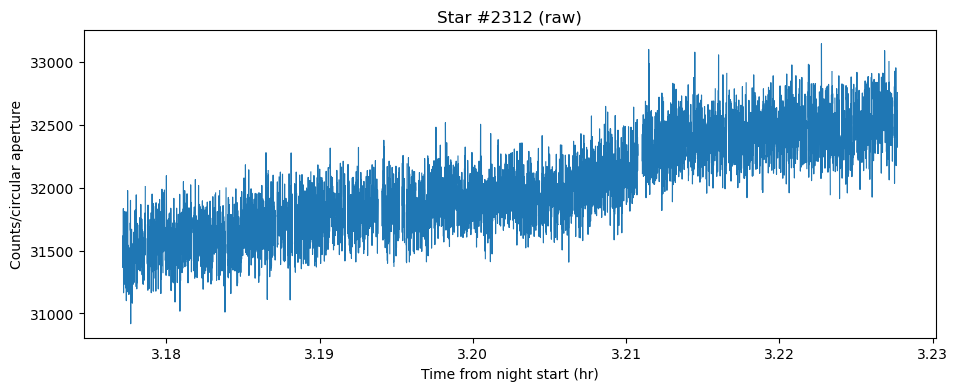

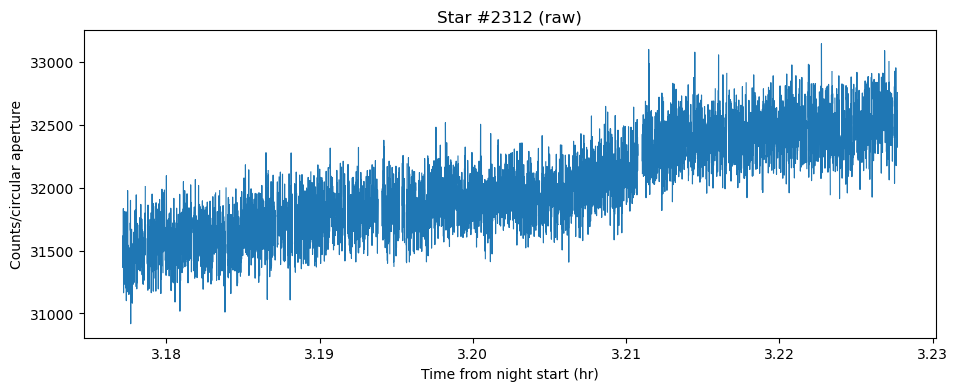

In [8]:
sid = int(bright.iloc[0]['star_id'])

# Single raw light curve.
lc = cat.get_raw_lightcurve(sid)
fig, ax = P.plot_single(lc, title=f'Star #{sid} (raw)')
fig


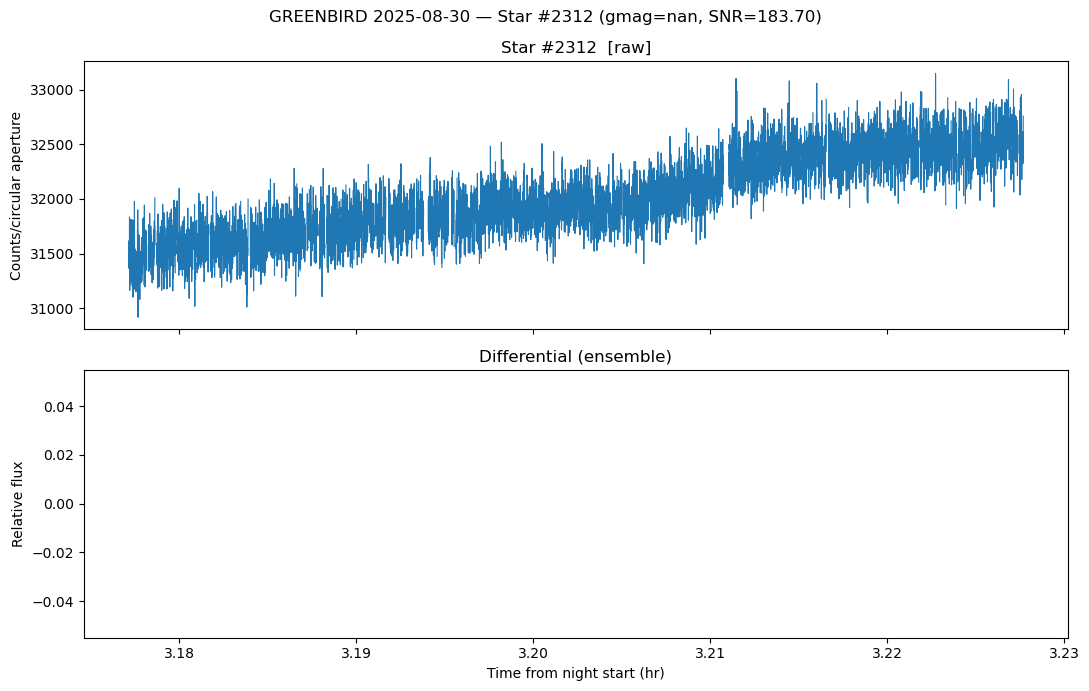

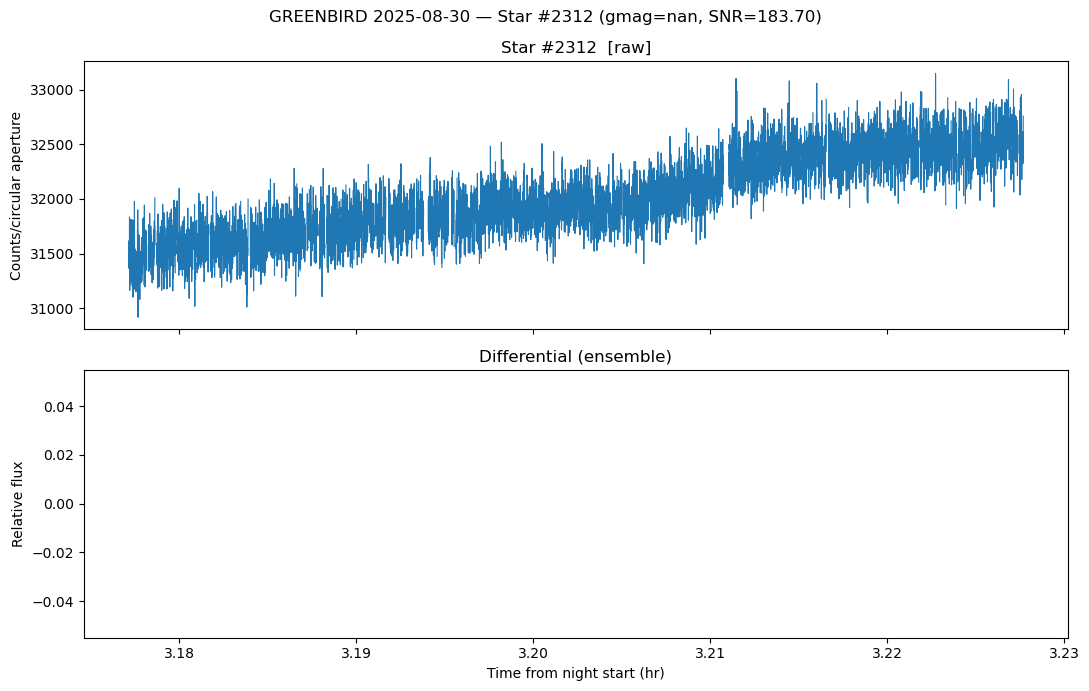

In [9]:
# Stacked raw vs. ensemble differential.
fig = P.plot_raw_vs_diff(cat, sid, comp_rad_pix=150.0)
fig

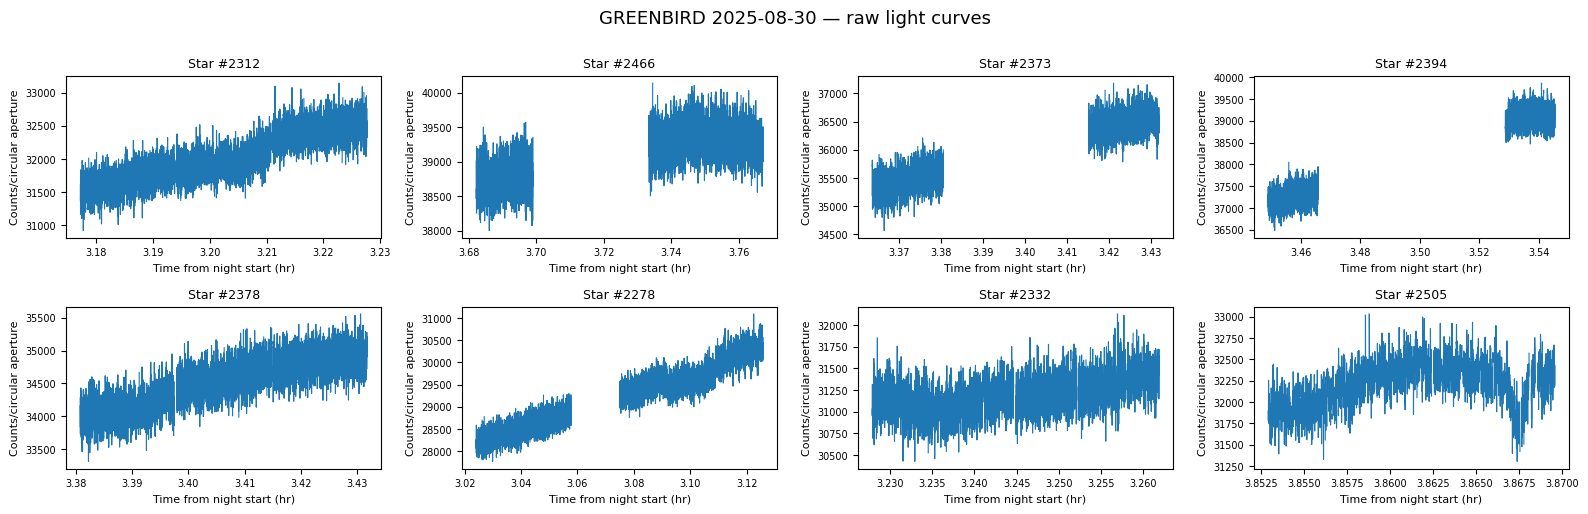

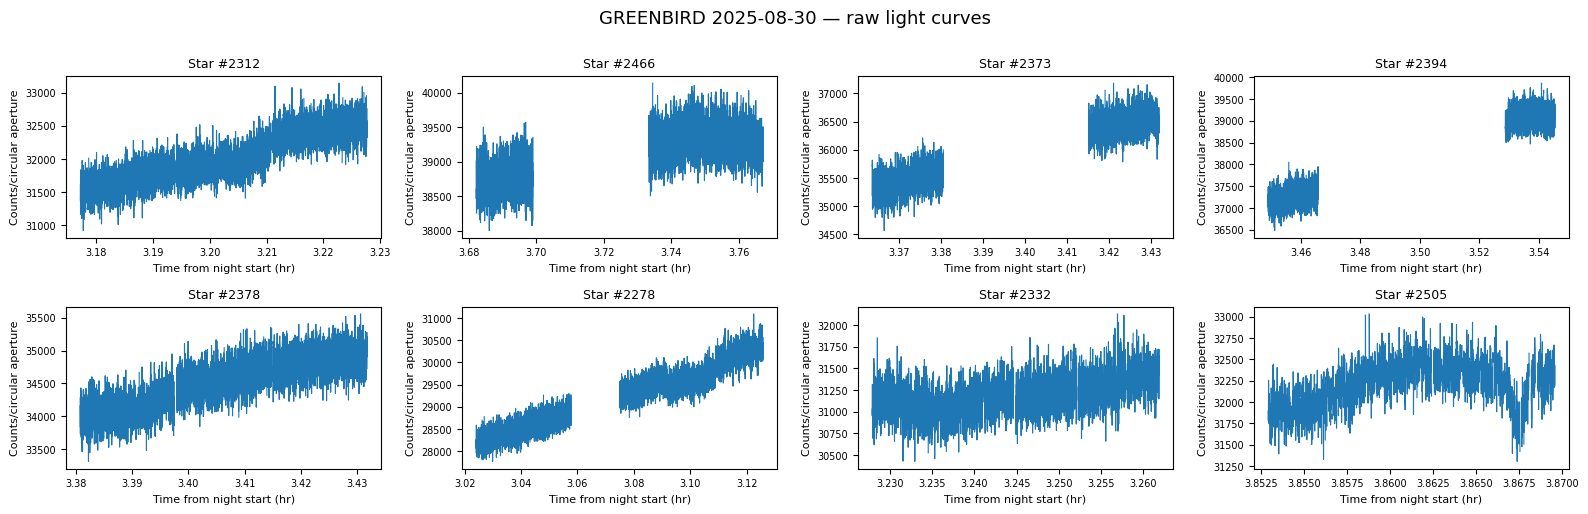

In [10]:
# Grid of the top several stars.
ids = [int(s) for s in bright['star_id'].head(8)]
fig = P.plot_multi_grid(cat, ids, kind='raw', ncols=4)
fig